In [2]:
import pandas as pd
import numpy as np

## Loading in our dataset 

We are using the dataset from [GSE277334](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE277334) retrieved from the Gene Expression Omnibus (GEO). 

This contains 763 liver transplant biopsies classified into four molecular genotypes, characterized by their gene expression: No-rejection (NR) 54%; TCMR 16%; NKRL 13%; and Injury 16%. 

This dataset has been pre-processed with the microarray probe labels replaced with genes named, while microarray probes referencing the same gene has also been combined. The features (genes) with low gene expressions of a median less than 3 has been removed from the dataset. This results in 18645 features for this dataset.

We load in the new dataset and see what it looks like. 

In [3]:
path = "../Checkpoint2_Microarray_Processing/GSE277334_expression_collapsed_filtered.csv"
path_target = "../Checkpoint2_Microarray_Processing/GSE277334_metadata.csv"

df = pd.read_csv(path)
target = pd.read_csv(path_target)

In [4]:
display(df.shape) # (18645, 764), where one column is for the "Gene Symbol"
display(target.shape) # (763, 2)

(18645, 764)

(763, 2)

In [5]:
display(df.columns)
display(df.describe())
display(df.head())

Index(['Gene Symbol', 'GSM8519505', 'GSM8519506', 'GSM8519507', 'GSM8519508',
       'GSM8519509', 'GSM8519510', 'GSM8519511', 'GSM8519512', 'GSM8519513',
       ...
       'GSM8520258', 'GSM8520259', 'GSM8520260', 'GSM8520261', 'GSM8520262',
       'GSM8520263', 'GSM8520264', 'GSM8520265', 'GSM8520266', 'GSM8520267'],
      dtype='object', length=764)

,GSM8519505,GSM8519506,GSM8519507,GSM8519508,GSM8519509,GSM8519510,GSM8519511,GSM8519512,GSM8519513,GSM8519514,...,GSM8520258,GSM8520259,GSM8520260,GSM8520261,GSM8520262,GSM8520263,GSM8520264,GSM8520265,GSM8520266,GSM8520267
count,18645.000000,18645.000000,18645.000000,18645.000000,18645.000000,18645.000000,18645.000000,18645.000000,18645.000000,18645.000000,...,18645.000000,18645.000000,18645.000000,18645.000000,18645.000000,18645.000000,18645.000000,18645.000000,18645.000000,18645.000000
mean,6.279595,6.281209,6.278919,6.273522,6.264295,6.272180,6.283976,6.269283,6.298402,6.278320,...,6.307767,6.313048,6.305291,6.287401,6.295183,6.291115,6.290827,6.291875,6.339847,6.282816
std,2.028491,2.042245,2.016224,2.084042,2.061609,2.030182,2.040548,2.033097,2.017384,2.048672,...,2.030470,1.993861,2.055414,2.048679,2.049861,2.056548,2.063699,2.035499,1.971140,2.078561
min,2.990000,2.930000,2.800000,2.940000,2.890000,2.940000,2.860000,2.810000,2.890000,2.850000,...,2.910000,2.690000,2.840000,2.930000,2.830000,2.830000,2.940000,2.840000,2.780000,2.720000
25%,4.670000,4.650000,4.660000,4.580000,4.580000,4.635000,4.640000,4.640000,4.680000,4.635000,...,4.700000,4.740000,4.640000,4.655000,4.660000,4.645000,4.630000,4.680000,4.820000,4.590000
50%,5.990000,5.980000,6.030000,5.970000,5.975000,6.000000,5.990000,5.990000,6.020000,5.990000,...,6.020000,6.060000,6.030000,6.010000,6.020000,5.990000,6.010000,6.000000,6.070000,6.010000
75%,7.545000,7.555000,7.560000,7.610000,7.590000,7.560000,7.560000,7.545000,7.560000,7.560000,...,7.545000,7.540000,7.600000,7.550000,7.560000,7.560000,7.610000,7.535000,7.490000,7.625000
max,14.590000,14.540000,14.600000,14.520000,14.540000,14.630000,14.590000,14.610000,14.540000,14.580000,...,14.580000,14.540000,14.540000,14.570000,14.590000,14.550000,14.530000,14.550000,14.560000,14.560000


,Gene Symbol,GSM8519505,GSM8519506,GSM8519507,GSM8519508,GSM8519509,GSM8519510,GSM8519511,GSM8519512,GSM8519513,...,GSM8520258,GSM8520259,GSM8520260,GSM8520261,GSM8520262,GSM8520263,GSM8520264,GSM8520265,GSM8520266,GSM8520267
0,A1BG,13.100,13.07,13.160,13.120,13.370,13.290,13.240,12.980,13.010,...,13.210,13.33,13.370,13.500,12.690,12.970,13.060,12.980,11.75,12.940
1,A1CF,11.485,11.38,10.585,10.900,11.145,10.810,11.070,11.210,11.000,...,11.445,11.48,11.325,11.245,11.300,11.595,10.645,11.455,9.86,11.055
2,A2BP1,3.645,3.72,3.455,3.575,3.525,3.415,3.625,3.575,3.675,...,3.595,3.81,3.600,3.685,3.665,3.780,3.565,3.750,3.57,3.475
3,A2LD1,6.430,7.00,6.120,6.330,6.850,6.300,6.330,6.710,7.030,...,6.460,6.83,6.540,6.260,6.710,7.180,7.370,7.480,7.38,6.290
4,A2M,12.720,13.16,13.160,13.340,12.620,13.190,12.960,13.530,12.690,...,12.800,13.21,12.630,13.040,12.420,12.720,12.860,12.390,12.05,13.130


In [6]:
df.isna().sum()

Gene Symbol    1
GSM8519505     0
GSM8519506     0
GSM8519507     0
GSM8519508     0
              ..
GSM8520263     0
GSM8520264     0
GSM8520265     0
GSM8520266     0
GSM8520267     0
Length: 764, dtype: int64

Note we have one `NaN` in our list of gene symbols, we will address this later. 

## Transpose our dataset

Note our rows are defined as the genes while our columns are our sample. We want to transpose it so that our genes are columns to represent our features.

In [7]:
df_temp = df.copy().set_index('Gene Symbol')
df_T = df_temp.T
print(df_T.head())
df_T.columns[-3:]

Gene Symbol   A1BG    A1CF  A2BP1  A2LD1    A2M  A2ML1  A3GALT2  A4GALT  \
GSM8519505   13.10  11.485  3.645   6.43  12.72  3.580     4.24   3.960   
GSM8519506   13.07  11.380  3.720   7.00  13.16  3.310     4.21   4.175   
GSM8519507   13.16  10.585  3.455   6.12  13.16  3.370     4.11   4.105   
GSM8519508   13.12  10.900  3.575   6.33  13.34  3.270     4.24   4.130   
GSM8519509   13.37  11.145  3.525   6.85  12.62  3.605     4.15   4.090   

Gene Symbol  A4GNT   AAA1  ...   ZXDB   ZXDC  ZYG11A  ZYG11B    ZYX  ZZEF1  \
GSM8519505    5.13  3.615  ...  5.975  6.565   3.655   7.195  7.785  7.405   
GSM8519506    4.88  3.545  ...  5.415  6.560   3.520   6.695  7.505  7.380   
GSM8519507    4.92  3.545  ...  5.505  6.800   3.115   6.880  7.815  7.545   
GSM8519508    4.73  3.480  ...  6.580  6.630   3.275   7.600  8.145  7.250   
GSM8519509    4.74  3.460  ...  5.785  6.845   3.210   7.155  7.815  7.535   

Gene Symbol   ZZZ3    NaN  selenoprotein 15  tAKR  
GSM8519505   8.165  8.160   

Index([nan, 'selenoprotein 15', 'tAKR'], dtype='object', name='Gene Symbol')

# Removing the NaN column

We see there is a column with name `NaN`, which corresponds to markers from the microarray that did not have an identifiable gene attached to it. We remove it below.

In [8]:
print(df_T.shape) # (763, 18645)
df_T = df_T.drop(columns=[np.nan])
print(df_T.shape) # (763, 18644)

df_T.columns[-3:] # We see our NaN label is now gone

(763, 18645)
(763, 18644)


Index(['ZZZ3', 'selenoprotein 15', 'tAKR'], dtype='object', name='Gene Symbol')

In [9]:
# Checking we have no more NaN values anywhere. 

df_T.isna().sum().sum()


0

# Exploring the labels 

We want to see what our target labels are, and the distribution of each group. 

In [10]:
display(target['Cluster'].value_counts())
display(target.head())

Cluster
NR        415
TCMR      125
Injury    125
NKRL       98
Name: count, dtype: int64

,Sample,Cluster
0,GSM8519505,NR
1,GSM8519506,NKRL
2,GSM8519507,TCMR
3,GSM8519508,Injury
4,GSM8519509,NR


## Adjusting the labels 
The original labels used by the paper is defined by 
- NR: Non-rejection (non-rejection)       
- TCMR: T cell-mediated rejection (rejection)
- Injury (non-rejection)
- NKRL: NK cell-enriched rejection-like state (rejection)

We want to classify by rejection or non-rejections, so we changed them to be:
- 0: non-rejection  
- 1: rejection


In [11]:
target_adjusted = target.copy()

target_adjusted.loc[target['Cluster'].isin(['NR', 'Injury']), 'Cluster'] = 0
target_adjusted.loc[target['Cluster'].isin(['TCMR', 'NKRL']), 'Cluster'] = 1

target_adjusted.head()


,Sample,Cluster
0,GSM8519505,0
1,GSM8519506,1
2,GSM8519507,1
3,GSM8519508,0
4,GSM8519509,0


## Split into Training and Testing set

Now that we have cleaned up our data, we will split into the training and test sets for further use.

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(df_T, target_adjusted, random_state=123, test_size=0.2)

Checking the split between the two groups remains proportional between the training and testing set.

In [14]:
print(y_train['Cluster'].value_counts())
print(y_test['Cluster'].value_counts())
print('\n')

print(y_train['Cluster'].value_counts(normalize=True))
print(y_test['Cluster'].value_counts(normalize=True))


Cluster
0    432
1    178
Name: count, dtype: int64
Cluster
0    108
1     45
Name: count, dtype: int64


Cluster
0    0.708197
1    0.291803
Name: proportion, dtype: float64
Cluster
0    0.705882
1    0.294118
Name: proportion, dtype: float64


In [15]:
X_train.to_csv('/Users/goncabulbul/Desktop/Liver/update2024paper/X_train.csv')
X_test.to_csv('/Users/goncabulbul/Desktop/Liver/update2024paper/X_test.csv')

y_train.to_csv('/Users/goncabulbul/Desktop/Liver/update2024paper/y_train.csv')
y_test.to_csv('/Users/goncabulbul/Desktop/Liver/update2024paper/y_test.csv')

## Loading prerocessed train/test splits

Using cleaned and filtered gene expression data for exploratory analysis. X_train contains features(genes), y_train target(cluster) information.

In [16]:
X_train = pd.read_csv('/Users/goncabulbul/Desktop/Liver/update2024paper/X_train.csv', index_col=0)
y_train = pd.read_csv('/Users/goncabulbul/Desktop/Liver/update2024paper/y_train.csv', index_col=0).squeeze()  # converts the target from a single-column DataFrame to a Series for easier handling.

# Quick check of shapes and target distribution
print("X_train shape:", X_train.shape)
print("y_train distribution:\n", y_train.value_counts())


X_train shape: (610, 18644)
y_train distribution:
 Sample      Cluster
GSM8519505  0          1
GSM8520012  0          1
GSM8520005  0          1
GSM8520006  1          1
GSM8520007  0          1
                      ..
GSM8519771  1          1
GSM8519772  0          1
GSM8519773  0          1
GSM8519775  0          1
GSM8520267  0          1
Name: count, Length: 610, dtype: int64


# Visualize target class distribution

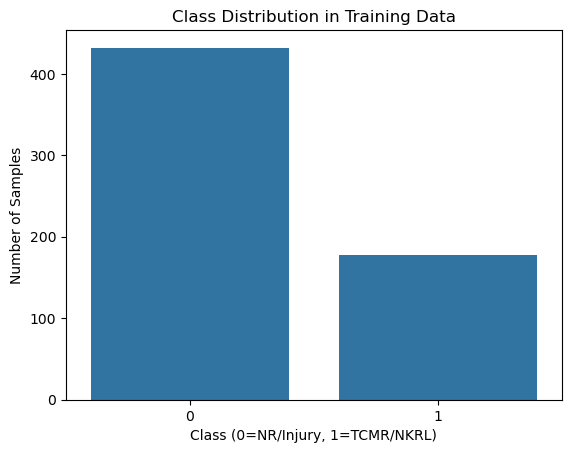

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot directly from the DataFrame column (our y-train contains 2 columns, one with the sample ID, other is the cluster information
sns.countplot(x='Cluster', data=y_train)
plt.title("Class Distribution in Training Data")
plt.xlabel("Class (0=NR/Injury, 1=TCMR/NKRL)")
plt.ylabel("Number of Samples")
plt.show()



# Summary statistics of gene expression
Check distribution, mean, variance of features from the first 5 columns (genes)

Mean: mean expression values from all the samples
std: standard deviation, smaller better
min: min expression level; how much the gene varies across samples

Explaining percentale values from one of the genes that we have (A1BG gene)
Statistic	Value	Interpretation
25% (Q1)	13.00	25% of samples have expression ≤ 13.00
50% (Median)	13.16	Half of the samples have expression ≤ 13.16
75% (Q3)	13.28	75% of samples have expression ≤ 13.28

A2BP1 have low median but a few high outliers. Difference between min and max is high.

In [18]:
# On whole data-set

print("Gene expression summary statistics (first 5 features):")
print(df_T.iloc[:, :5].describe().T)


Gene expression summary statistics (first 5 features):
             count       mean       std    min      25%    50%     75%     max
Gene Symbol                                                                   
A1BG         763.0  13.061887  0.623968  5.630  13.0000  13.16  13.280  13.650
A1CF         763.0  11.071933  0.650199  4.640  10.9675  11.20  11.380  11.965
A2BP1        763.0   3.678702  0.351646  3.285   3.5650   3.63   3.710   8.490
A2LD1        763.0   6.608414  0.680316  4.180   6.1550   6.59   7.040   8.690
A2M          763.0  12.832962  0.482284  9.520  12.6100  12.91  13.145  13.720


In [19]:
# Check for missing values

print("Missing values per feature:\n", df_T.isnull().sum().sum())


Missing values per feature:
 0


## Correlation Heatmap of Top Variable Genes
Objective: Explore relationships between the most variable genes.
Identify clusters of genes that move together.
Helps understand redundancy and potential patterns before modeling.

Most variable genes meaning: variance measures how much a feature (for example: gene expresssion of a specific gene in our case) changes across sample. Variable genes are genes whose expression levels fluctuate a lot across samples.
Low-variance genes do not fluctuate, stay moslty constant in all samples and usually carry little information for distinguishing classes.

For ex: 
Low-variance a gene always expressed at 12 ± 0.01.	Not useful for classification, adds noise.
High-variance a gene ranges from 2 to 15 across samples.	Potentially informative; might differ between rejection vs. non-rejection.

Variable genes: They may or may not separate our classes; they are just interesting for exploring patterns.
Later, modeling or differential expression identifies which ones truly distinguish rejection vs. non-rejection.

.corr() calculates Pearson correlation between each pair of genes.
Values range from -1 to 1:
1 → perfectly positively correlated
0 → no correlation
-1 → perfectly negatively correlated

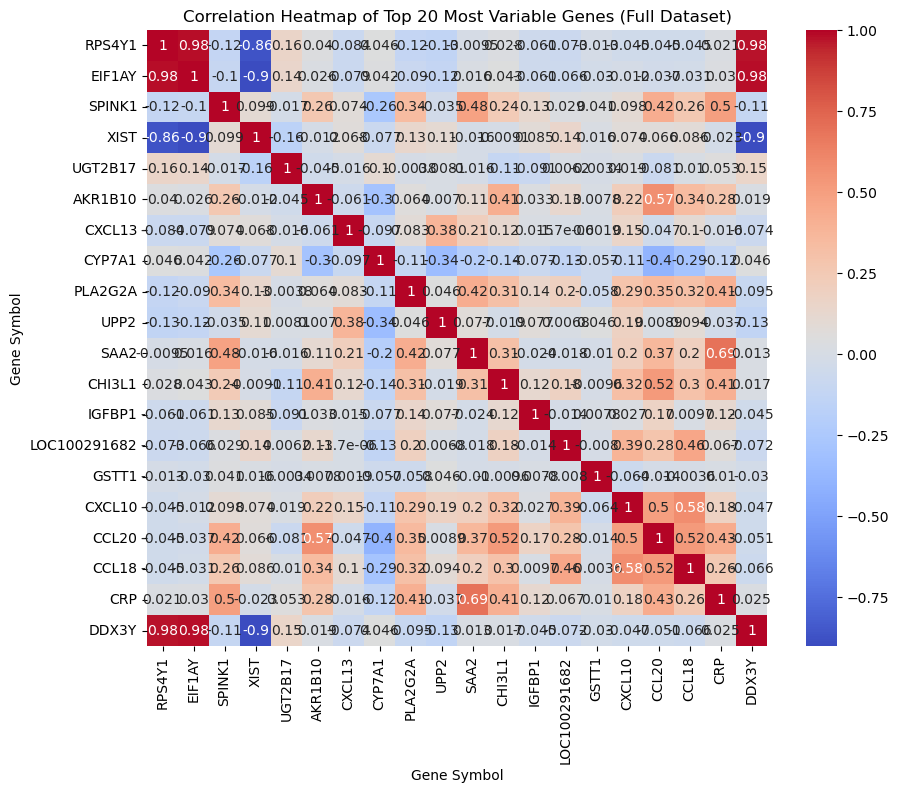

In [20]:

# Calculate variance for each gene (from whole dataset)
gene_variances = df_T.var().sort_values(ascending=False)

# Select top 20 most variable genes
top_genes = gene_variances.head(20).index
corr_matrix = df_T[top_genes].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Top 20 Most Variable Genes (Full Dataset)")
plt.show()


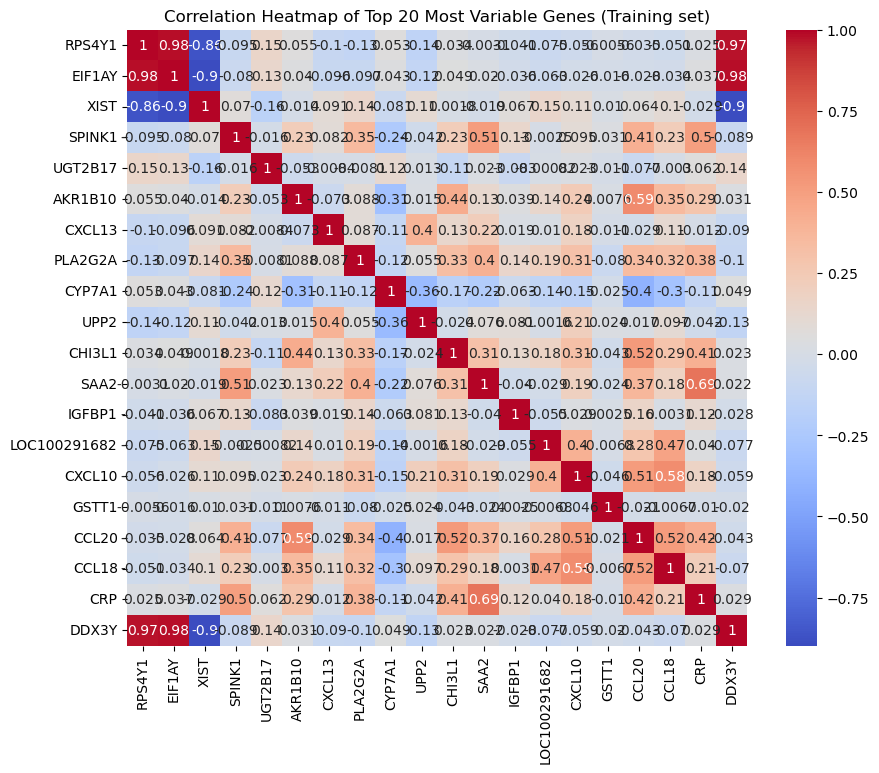

In [21]:
# Calculate variance for each gene   (from training set)
gene_variances = X_train.var().sort_values(ascending=False)

# Select top 20 most variable genes
top_genes = gene_variances.head(20).index
corr_matrix = X_train[top_genes].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Top 20 Most Variable Genes (Training set)")
plt.show()


## Interpretation of the correlation heatmap

Both rows and columns represent the same genes (top 20 variable genes in our case).Each cell at the intersection of a row and column shows the correlation coefficient between those two genes.
Correlation values range from -1 to 1:

1 (dark red or max color) → perfectly positively correlated (both genes increase/decrease together)
0 (white or neutral color) → no linear relationship
-1 (dark blue or min color) → perfectly negatively correlated (one increases while the other decreases)

Patterns to Look For
Clusters of high correlation (red blocks)
Genes in the same block may be co-regulated or part of the same pathway.
Could indicate redundancy in features for modeling.

Negative correlations (blue blocks)
Genes that behave in opposite directions.
Can be biologically interesting or help separate classes.

Independent genes (white/neutral)
These genes vary independently of others and may carry unique information.


# Principal Component Analysis (PCA) — overview and interpretation

**Goal.** Use PCA to reduce the high-dimensional gene expression matrix to two dimensions so we can visualize whether samples separate by class (rejection vs non-rejection).

**What the code does.**
- PCA is fit to `df_T`, the transposed gene-expression matrix. Transposition ensures rows are samples and columns are features (genes).
- We request two components (`n_components=2`) and project each sample into the PC1–PC2 space using `fit_transform`.
- The projected coordinates are combined with class labels (`target_adjusted['Cluster']`) to produce a scatter plot colored by class.
- `pca.explained_variance_ratio_` reports the fraction of total variance explained by each principal component; this helps judge how much of the dataset structure is captured by PC1 and PC2.

**How to read the plot and numbers.**
- If samples of different classes form distinct clusters (or partially separate) in PC1–PC2 space, that indicates global expression differences captured by the leading principal axes.
- If classes overlap strongly, either (a) major axes of variance are driven by other factors (batch effects, sample composition) or (b) class differences are subtle and not dominant global signals.


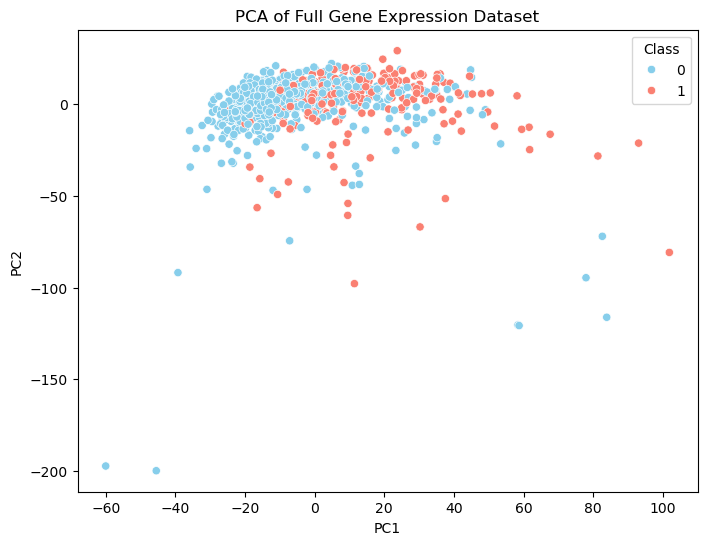

Explained variance by PC1 and PC2: [0.16359382 0.14712564]


In [23]:

# Principal Component Analysis (PCA)
# Purpose: Reduce dimensionality and visualize sample clustering

from sklearn.decomposition import PCA

# Fit PCA on the full transposed dataset
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_T)

# Combine PCA result with class labels for plotting

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Class'] = target_adjusted['Cluster'].values  # use full dataset labels

# Scatter plot of the first 2 principal components
plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='Class', data=pca_df, palette=['skyblue','salmon'])
plt.title("PCA of Full Gene Expression Dataset")
plt.show()

# Explained variance of the first 2 principal components
print("Explained variance by PC1 and PC2:", pca.explained_variance_ratio_[:2])




PC1 is the axis capturing the most variation, PC2 captures the second most.

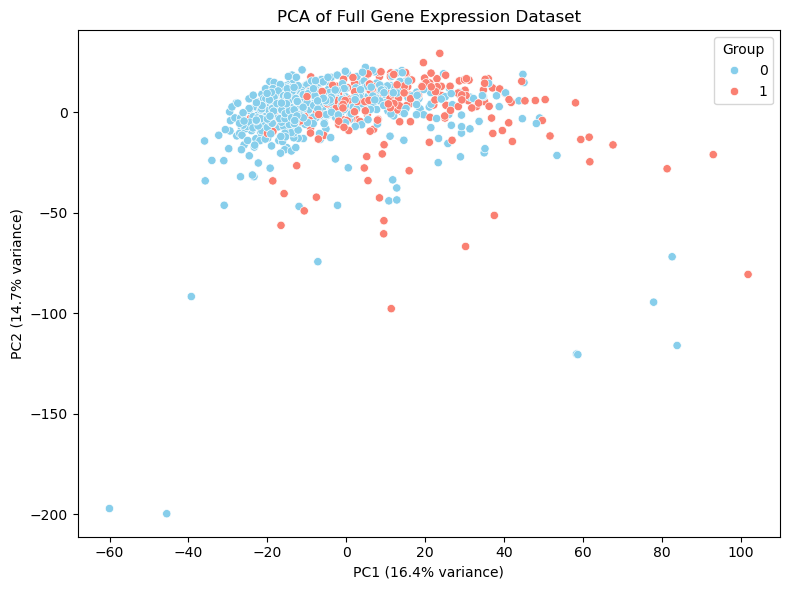

In [24]:
## This PCA is the same as above. I am just including the variance on the x and y axis for presentation

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_T)

# Combine PCA result with class labels for plotting

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Class'] = target_adjusted['Cluster'].values  # use full dataset labels

# Scatter plot of the first 2 principal components
plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='Class', data=pca_df, palette=['skyblue','salmon'])
plt.title("PCA of Full Gene Expression Dataset")

# Including the variance on the x and y axis for presentation

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Group")
plt.tight_layout()
plt.show()

In [25]:

# PC1 loadings for the full dataset
pc1_loadings = pd.Series(pca.components_[0], index=df_T.columns)

# Top 10 genes contributing most to PC1
top_pc1_genes = pc1_loadings.abs().sort_values(ascending=False).head(10)

print("Top 10 genes driving PC1 (full dataset):")
print(top_pc1_genes)


Top 10 genes driving PC1 (full dataset):
Gene Symbol
EFEMP1    0.064165
CCL20     0.060955
CCL18     0.057322
FABP5     0.054905
KCNN2     0.053894
BBOX1     0.050151
SPINK1    0.049336
THBS2     0.049226
CXCL11    0.047377
GSTA2     0.047255
dtype: float64


In [26]:
# PC2 loadings
pc2_loadings = pd.Series(pca.components_[1], index=df_T.columns)

# Top 10 genes contributing most to PC2 (absolute value)
top_pc2_genes = pc2_loadings.abs().sort_values(ascending=False).head(10)

print("Top 10 genes driving PC2:")
print(top_pc2_genes)


Top 10 genes driving PC2:
Gene Symbol
PAH        0.041095
CFB        0.039370
ADH6       0.037242
AADAC      0.035433
SLC38A4    0.035098
CP         0.034896
HAO1       0.034502
CFHR4      0.034144
F13B       0.033923
HPX        0.033909
dtype: float64


# Per-gene differential expression: Welch's t-test with FDR correction

**Goal: Test each gene for differential expression between two sample groups (Rejection vs NonRejection) using Welch’s t-test (unequal variance). Correct p-values for multiple testing using the Benjamini–Hochberg false discovery rate (FDR).

**Explanation of the code:**
- Copies the transposed expression table `df_T` into `df_final` and adds a `Group` column with class labels.
- Identifies gene columns (all columns except `Group`) and splits samples into `Rejection` and `NonRejection`.
- For each gene, runs a Welch’s t-test and stores t-statistic, raw p-value, and group means. If a group has fewer than 2 observations for a gene, returns `NaN` for the test statistics.
- Adjusts raw p-values for multiple testing using the Benjamini–Hochberg procedure (`fdr_bh`) and computes log2 fold-change (`log2FC`) between group means.
- Sorts results by adjusted p-value and writes them to CSV for downstream inspection.


In [27]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# Prepare data
df_final = df_T.copy()
df_final['Group'] = target_adjusted['Cluster'].values  # 0 = NonRejection, 1 = Rejection

# Map numeric clusters to string labels
df_final['Group'] = df_final['Group'].map({0:'NonRejection', 1:'Rejection'})

# Identify gene columns
gene_cols = df_final.columns.drop('Group')

# Split groups
rejection = df_final[df_final['Group'] == 'Rejection']
nonrejection = df_final[df_final['Group'] == 'NonRejection']

# Per-gene Welch's t-test
results = []
for gene in gene_cols:
    x1 = rejection[gene].dropna()
    x2 = nonrejection[gene].dropna()
    if (len(x1) < 2) or (len(x2) < 2):
        results.append({'Gene': gene, 't_stat': np.nan, 'p_value': np.nan,
                        'mean_Rejection': x1.mean() if len(x1)>0 else np.nan,
                        'mean_NonRejection': x2.mean() if len(x2)>0 else np.nan})
        continue
    t_stat, p_val = ttest_ind(x1, x2, equal_var=False)
    results.append({'Gene': gene, 't_stat': t_stat, 'p_value': p_val,
                    'mean_Rejection': x1.mean(), 'mean_NonRejection': x2.mean()})

t_results = pd.DataFrame(results)

# FDR correction
valid = t_results['p_value'].notna()
p_adj = np.full(len(t_results), np.nan)
if valid.sum() > 0:
    p_adj_vals = multipletests(t_results.loc[valid, 'p_value'], method='fdr_bh')[1]
    p_adj[valid] = p_adj_vals
t_results['p_adj'] = p_adj

# Log2 fold-change
eps = 1e-9
t_results['log2FC'] = np.log2((t_results['mean_Rejection'] + eps) / (t_results['mean_NonRejection'] + eps))

# Sort by adjusted p-value
t_results = t_results.sort_values('p_adj', na_position='last').reset_index(drop=True)

# Save results 
t_results.to_csv("t_results_full gene expression.csv", index=False)
print("Saved t-test results to: t_results_full gene expression.csv")


Saved t-test results to: t_results_full gene expression.csv


# Visualization of Top 5 Differentially Expressed Genes

**Goal.** Plot expression distributions of the top 5 most significant genes (lowest adjusted p-values) between the two sample groups: *Rejection* and *NonRejection*.

**Step-by-step summary:**
1. **Select top genes:**  
   - If adjusted p-values (`p_adj`) exist, the top 5 genes with the smallest `p_adj` are selected.  
   - If no adjusted p-values (all `NaN`), fallback to raw p-values.
2. **Reshape data for plotting:**  
   - The expression matrix (`df_final`) is subset to include only those top genes + the `Group` column.  
   - Data are then “melted” into long format suitable for Seaborn (`Gene`, `Expression`, `Group`).
3. **Plot expression distributions:**  
   - A **boxplot** shows median and variability of expression per gene in each group.  
   - A **stripplot** overlays individual sample points to visualize spread and outliers.
4. **Formatting and aesthetics:**  
   - Duplicate legend entries (from both boxplot and stripplot) are removed.  
   - Plot title and layout are adjusted for readability.

**How to interpret the plot:**
- Each gene appears on the x-axis.
- The y-axis shows expression level.
- Two colors correspond to groups (*Rejection* vs *NonRejection*).
- If one color’s box is consistently higher or lower than the other, that gene shows differential expression.
- The smaller the adjusted p-value, the more statistically confident that the difference between the two groups is unlikely due to random variation.


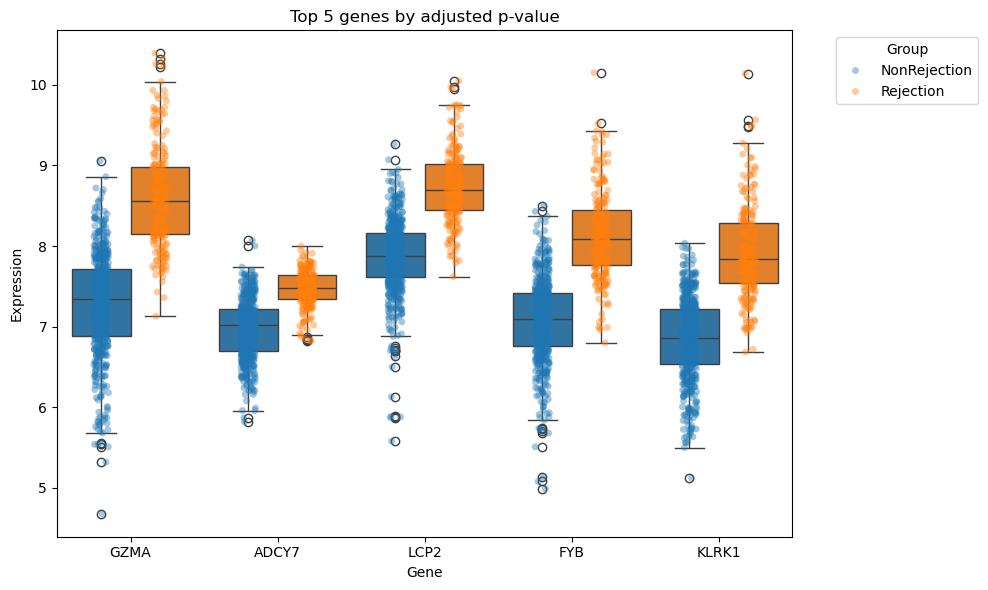

In [28]:
# Select top 5 genes 
if t_results['p_adj'].notna().sum() > 0:
    top5 = t_results.sort_values(['p_adj', 'p_value'], na_position='last').head(5)['Gene'].tolist()
else:
    top5 = t_results.sort_values('p_value', na_position='last').head(5)['Gene'].tolist()

# Plot top 5 genes 
if len(top5) > 0:
    df_plot = df_final[top5 + ['Group']].reset_index().melt(id_vars=['index','Group'], 
                                                            var_name='Gene', value_name='Expression')
    
    plt.figure(figsize=(10,6))
    
    # Boxplot
    sns.boxplot(data=df_plot, x='Gene', y='Expression', hue='Group', dodge=True)
    
    # Stripplot on top for individual points
    sns.stripplot(data=df_plot, x='Gene', y='Expression', hue='Group', dodge=True, 
                  jitter=True, alpha=0.4 )
    
    # Deduplicate legend
    handles, labels = plt.gca().get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    plt.legend(unique.values(), unique.keys(), title='Group', bbox_to_anchor=(1.05,1), loc='upper left')
    
    plt.title('Top 5 genes by adjusted p-value')
    plt.tight_layout()
    plt.show()
else:
    print("No top genes to plot.")


In [29]:
# Table summary for top 5 genes
top5_summary = t_results.set_index('Gene').loc[top5, 
                                               ['mean_Rejection', 'mean_NonRejection', 'log2FC', 'p_adj']]
top5_summary = top5_summary.rename(columns={
    'mean_Rejection': 'Mean (Rejection)',
    'mean_NonRejection': 'Mean (NonRejection)',
    'log2FC': 'log2 Fold-Change',
    'p_adj': 'Adjusted p-value'
})

print("Summary of Top 5 Genes:")
display(top5_summary.style.format({
    'Mean (Rejection)': "{:.3f}",
    'Mean (NonRejection)': "{:.3f}",
    'log2 Fold-Change': "{:.3f}",
    'Adjusted p-value': "{:.2e}"
}))


Summary of Top 5 Genes:


,Mean (Rejection),Mean (NonRejection),log2 Fold-Change,Adjusted p-value
Gene,,,,
GZMA,8.613,7.279,0.243,1.68e-87
ADCY7,7.471,6.975,0.099,5.03e-80
LCP2,8.730,7.865,0.151,4.22e-78
FYB,8.143,7.080,0.202,1.59e-77
KLRK1,7.920,6.838,0.212,5.48e-75


# Aligning sample labels and colors for heatmap visualization

**Goal.** Prepare sample grouping information and color annotations for a clustered heatmap of gene expression data.

**Step-by-step summary:**

1. **Convert numeric cluster IDs to descriptive group names**
   - The dataset uses `0` and `1` to indicate class membership.  
   - These are mapped to string labels:  
     - `0 → NonRejection`  
     - `1 → Rejection`

2. **Align sample order between data and metadata**
   - The gene expression matrix (`df_T`) has samples as row indices.
   - The metadata table (`target_adjusted`) contains sample IDs in its `Sample` column.
   - The intersection of these two lists ensures both contain exactly the same samples, avoiding mismatched indices.

3. **Extract and align group labels**
   - Using `target_adjusted`, a new `group_labels` series is created, indexed by sample ID.
   - These labels are aligned with the same sample order as in `heatmap_df`.

4. **Sort samples by group**
   - To make the heatmap easier to interpret, samples are ordered so that all `NonRejection` samples appear together, followed by all `Rejection` samples.

5. **Assign colors to groups**
   - Each group label is mapped to a color for visual distinction:  
     - `NonRejection → skyblue`  
     - `Rejection → salmon`
   - These colors (`col_colors`) can be passed to seaborn’s `clustermap()` to visually annotate samples by group.

**Outcome.**
You get three aligned objects:
- `heatmap_sorted` → expression data (samples ordered by group)  
- `group_labels` → categorical labels for each sample  
- `col_colors` → color annotations matching group labels  

These ensure that the clustering and color bar on the heatmap correspond accurately to the biological groups.


In [30]:
# Map numeric cluster to string label
target_adjusted['Group'] = target_adjusted['Cluster'].map({0:'NonRejection', 1:'Rejection'})

# Align df_T and target_adjusted by Sample ID
common_samples = df_T.index.intersection(target_adjusted['Sample'])
heatmap_df = df_T.loc[common_samples]

# Map group labels to these samples
group_labels = target_adjusted.set_index('Sample').loc[common_samples, 'Group']

# Sort samples by Group
sorted_samples = group_labels.sort_values().index
heatmap_sorted = heatmap_df.loc[sorted_samples]

# Map colors to group
col_colors = group_labels.loc[sorted_samples].map({'NonRejection':'skyblue','Rejection':'salmon'})


# Heatmap of Top 20 Differentially Expressed Genes

**Goal.**
Visualize expression patterns of the top 20 genes (lowest adjusted p-values) across all samples, highlighting group-level differences between *Rejection* and *NonRejection*.

**Step-by-step explanation:**

1. **Select the most significant genes**
   - From the t-test results (`t_results`), the 20 genes with the lowest adjusted p-values (`p_adj`) are chosen.
   - These represent the most statistically significant expression differences between the two groups.

2. **Generate a clustered heatmap**
   - `sns.clustermap()` is used to create a hierarchical clustering heatmap.
   - Each **row** represents a gene, and each **column** represents a sample.

3. **Clustering strategy**
   - **Row clustering (`row_cluster=True`)** groups genes with similar expression profiles.
   - **Column clustering (`col_cluster=False`)** keeps samples in their original sorted order (so group separation remains clear).

4. **Group color annotation**
   - The `col_colors` bar above the heatmap shows sample group membership:
     - `skyblue → NonRejection`
     - `salmon → Rejection`
   - This color bar makes it easy to see how expression patterns align with clinical groups.

5. **Final presentation 
   - X and Y axis labels clarify what each dimension represents.
   - A legend is added using `matplotlib.patches.Patch` to label the color annotations.
   - The overall figure title: **“Top 20 Differentially Expressed Genes”** summarizes the content.


/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


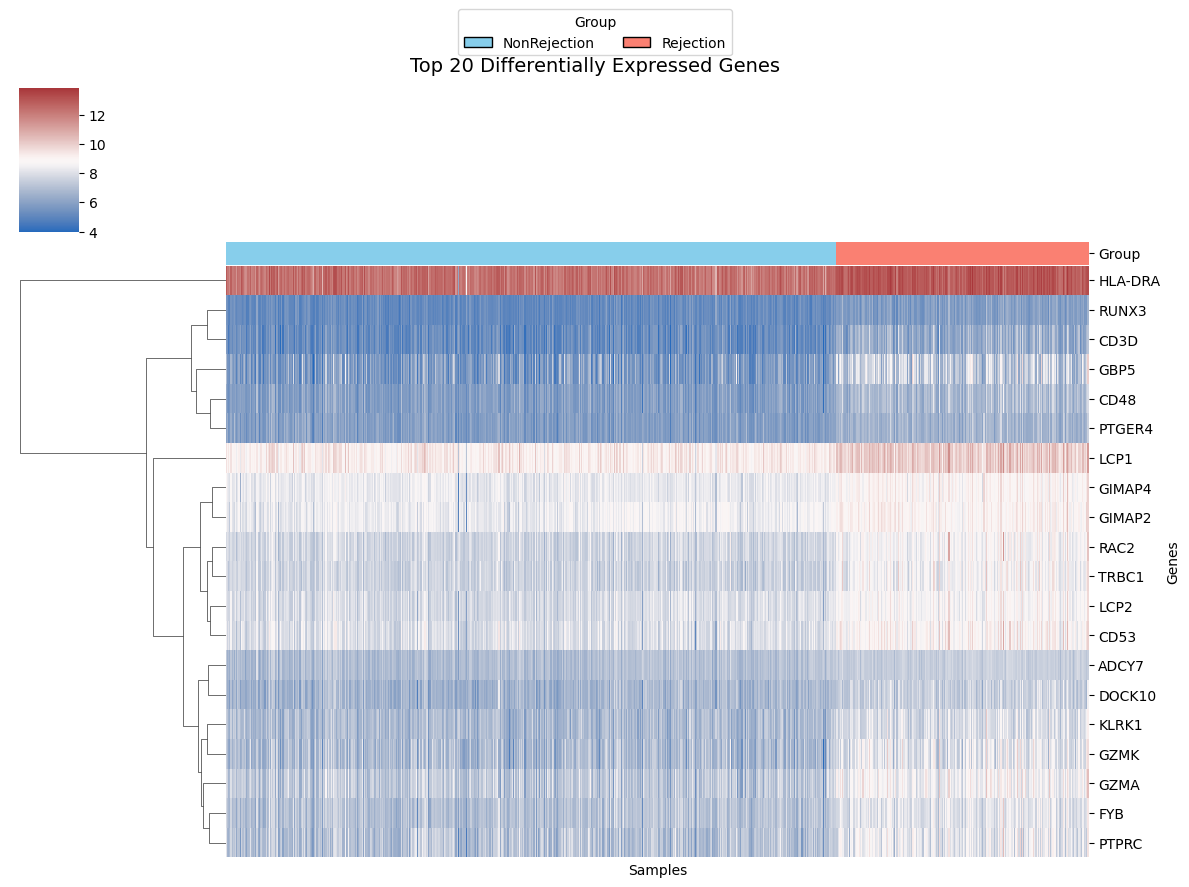

In [31]:
from matplotlib.patches import Patch
from scipy.stats import zscore

top20_genes = t_results.sort_values('p_adj', na_position='last').head(20)['Gene'].tolist()

g = sns.clustermap(
    heatmap_sorted[top20_genes].T,  # genes as rows
    cmap='vlag',
    row_cluster=True,
    col_cluster=False,
    figsize=(12,8),
    xticklabels=False,
    yticklabels=top20_genes,
    col_colors=col_colors
)

g.ax_heatmap.set_xlabel("Samples")
g.ax_heatmap.set_ylabel("Genes")
g.fig.suptitle("Top 20 Differentially Expressed Genes", y=1.02, fontsize=14)

legend_elements = [
    Patch(facecolor='skyblue', edgecolor='k', label='NonRejection'),
    Patch(facecolor='salmon', edgecolor='k', label='Rejection')
]
g.fig.legend(handles=legend_elements, title="Group", bbox_to_anchor=(0.5, 1.05), loc='center', ncol=2)

plt.show()


# Z-scored Heatmap of Top 20 Differentially Expressed Genes

**Goal.**
Visualize expression patterns of the top 20 significant genes (from t-test) across samples, after standardizing each gene to have mean 0 and standard deviation 1. This makes it easier to compare genes with different absolute expression levels.

**Step-by-step explanation:**

1. **Select top 20 DE genes**  
   - Based on lowest adjusted p-values (`p_adj`) from the t-test.

2. **Subset and convert expression data**  
   - Extract only the top genes from `heatmap_sorted` and ensure all values are numeric (`float`).

3. **Z-score per gene**  
   - For each gene, subtract the mean and divide by standard deviation.
   - This centers expression around 0 and scales variance to 1, allowing all genes to be plotted on the same scale.  
   - Any gene with zero variance is replaced with 0 to avoid division errors.

4. **Clip extreme z-scores**  
   - Limit z-scores to [-3, 3] to reduce the effect of outliers on color scaling.

5. **Create clustered heatmap**  
   - **Rows = genes**, **Columns = samples**.  
   - **Row clustering (`row_cluster=True`)** groups genes with similar patterns.  
   - **Column clustering (`col_cluster=False`)** preserves sample order (sorted by group).  
   - **Colormap = `vlag`**, diverging to highlight up- vs down-regulation.  
   - **Color range fixed** to [-3, 3] to ensure comparability across genes.

6. **Annotate groups with colors**  
   - `skyblue` = NonRejection  
   - `salmon` = Rejection  
   - Legend added for clarity.

**Interpretation:**
- Positive z-scores → higher-than-average expression for that gene across all samples.  
- Negative z-scores → lower-than-average expression.  
- Patterns of color blocks along rows show whether gene expression separates Rejection vs NonRejection groups.  
- Row clustering can reveal co-regulated or functionally related genes.


/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


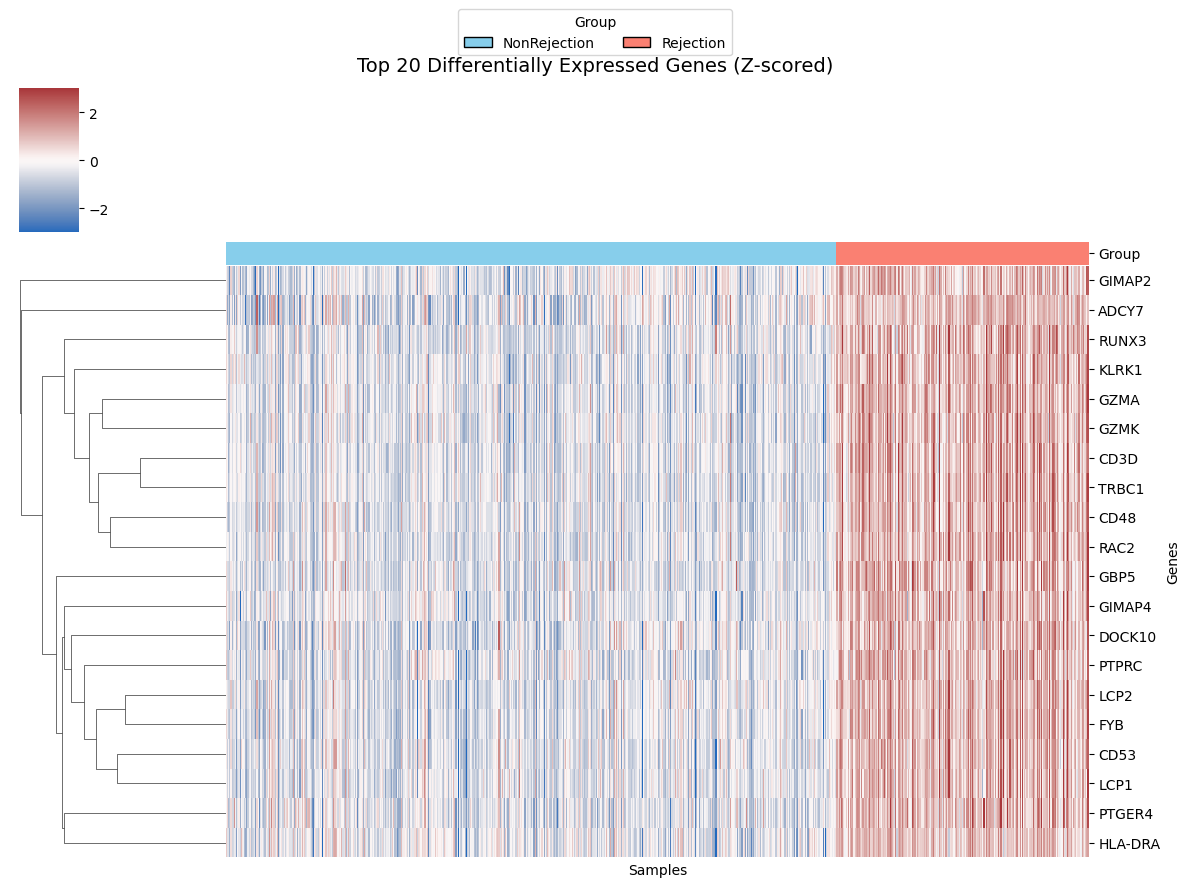

In [32]:
# Select top 20 DE genes 
top20_genes = t_results.sort_values('p_adj', na_position='last').head(20)['Gene'].tolist()

# Subset expression values 
heatmap_top = heatmap_sorted[top20_genes].astype(float)

# Z-score per gene
gene_means = heatmap_top.mean(axis=0)
gene_stds  = heatmap_top.std(axis=0, ddof=0).replace(0, np.nan)
heatmap_scaled = ((heatmap_top - gene_means) / gene_stds).fillna(0)

# Clip extreme z-scores for visualization 
heatmap_scaled = heatmap_scaled.clip(-3, 3)

# Create the clustered heatmap
g = sns.clustermap(
    heatmap_scaled.T,        # genes as rows
    cmap='vlag',
    vmin=-3, vmax=3,         # fix color range
    row_cluster=True,
    col_cluster=False,
    figsize=(12,8),
    xticklabels=False,
    yticklabels=top20_genes,
    col_colors=col_colors
)

g.ax_heatmap.set_xlabel("Samples")
g.ax_heatmap.set_ylabel("Genes")
g.fig.suptitle("Top 20 Differentially Expressed Genes (Z-scored)", y=1.02, fontsize=14)

# Legend 
legend_elements = [
    Patch(facecolor='skyblue', edgecolor='k', label='NonRejection'),
    Patch(facecolor='salmon', edgecolor='k', label='Rejection')
]
g.fig.legend(handles=legend_elements, title="Group", bbox_to_anchor=(0.5, 1.05), loc='center', ncol=2)

plt.show()



In [33]:
## Looking at raw expresion values of the genes on the heat map

# Select the top 20 genes
top20_genes = t_results.sort_values('p_adj', na_position='last').head(20)['Gene'].tolist()

# Subset your heatmap/expression data to only these genes
top20_table = heatmap_sorted[top20_genes]

# Optional: transpose so genes are rows, samples are columns
top20_table = top20_table.T

# Show the table
top20_table


,GSM8519505,GSM8519966,GSM8519968,GSM8519969,GSM8519971,GSM8519972,GSM8519975,GSM8519976,GSM8519965,GSM8519977,...,GSM8519679,GSM8519681,GSM8520024,GSM8519682,GSM8520021,GSM8519684,GSM8519685,GSM8520018,GSM8520123,GSM8519660
Gene Symbol,,,,,,,,,,,,,,,,,,,,,
GZMA,7.960,7.650,6.650,6.820,8.000,7.200,7.380,7.550,7.750,6.790,...,8.180,9.080,8.330,8.220,9.370,8.860,7.920,8.450,9.640,10.390
ADCY7,7.300,6.490,6.800,6.400,7.220,6.670,7.080,6.390,7.270,6.460,...,7.880,7.770,7.230,7.450,7.750,7.620,7.460,7.440,7.190,7.460
LCP2,8.200,7.830,7.700,7.680,8.620,7.560,7.590,7.890,8.380,7.460,...,8.800,8.790,8.450,8.730,8.960,8.930,8.370,8.700,8.900,9.740
FYB,7.780,7.140,6.760,6.620,7.680,6.780,7.040,7.070,7.040,6.210,...,8.100,8.170,7.630,7.670,8.510,8.420,7.660,7.800,7.990,9.430
KLRK1,7.540,7.225,6.610,6.370,7.580,6.625,7.550,7.315,7.585,6.360,...,7.345,8.765,7.335,7.835,8.010,7.880,7.680,8.025,8.560,9.210
DOCK10,7.280,6.420,6.560,5.810,7.030,6.110,6.680,6.880,7.010,6.090,...,6.820,7.560,7.090,7.140,7.690,7.850,7.330,7.130,6.660,8.520
CD53,8.460,7.660,8.135,7.605,8.635,7.560,7.760,7.785,8.055,6.900,...,8.005,8.890,8.530,8.320,9.240,9.080,8.520,8.900,9.605,9.980
CD48,6.280,5.630,5.320,5.520,6.100,5.735,5.845,5.840,6.070,5.565,...,7.355,6.965,6.265,6.505,7.400,6.735,6.480,6.625,7.445,7.870
RUNX3,5.590,5.425,4.885,4.820,5.505,5.320,5.440,5.710,5.270,5.030,...,6.215,6.050,5.595,6.010,5.870,6.255,5.620,5.690,5.655,6.630


In [35]:
## Exploring the mean expresion level of each gene from all the samples

# Select top 20 genes
top20_genes = t_results.sort_values('p_adj', na_position='last').head(20)['Gene'].tolist()

# Subset heatmap/expression data
top20_table = heatmap_sorted[top20_genes]

# Compute average expression per gene
gene_avg = top20_table.mean(axis=0)  # mean across samples (columns)
gene_avg = gene_avg.sort_values(ascending=False)  # optional: sort by avg expression

gene_avg


Gene Symbol
HLA-DRA    12.502634
LCP1        9.484450
GIMAP2      8.568794
GIMAP4      8.484941
CD53        8.260636
LCP2        8.117693
RAC2        7.987903
TRBC1       7.902831
GZMA        7.668952
PTPRC       7.433296
FYB         7.390891
GZMK        7.225269
KLRK1       7.154384
ADCY7       7.119987
DOCK10      6.920210
GBP5        6.265583
CD48        6.174607
PTGER4      6.106874
CD3D        5.577018
RUNX3       5.393506
dtype: float64

In [36]:
## Exploring the mean expression values of rejection and non-rejection groups

# It should be mapped as 'NonRejection' / 'Rejection'
heatmap_sorted['Group'] = group_labels.loc[heatmap_sorted.index]

# Select top 20 genes
top20_genes = t_results.sort_values('p_adj', na_position='last').head(20)['Gene'].tolist()

# Compute mean expression per gene for each group
group_means = heatmap_sorted.groupby('Group')[top20_genes].mean().T

# Sort by difference (optional)
group_means['Diff'] = group_means['Rejection'] - group_means['NonRejection']
group_means = group_means.sort_values('Diff', ascending=False).drop(columns='Diff')

group_means


Group,NonRejection,Rejection
Gene Symbol,,
GBP5,5.775870,7.451435
GZMA,7.279167,8.612825
GZMK,6.835593,8.168879
PTPRC,7.076185,8.298049
CD3D,5.247204,6.375673
KLRK1,6.838241,7.919933
FYB,7.080241,8.143139
CD53,7.966157,8.973722
TRBC1,7.609944,8.612063


# PCA on Top 20 Differentially Expressed Genes

** I am running PCA again after we sorted the top 20 differentially expressed genes by t-test. The variance is improved to 80% showing a clear seperation between rejection and non-rejection groups.

**Goal.** Reduce the dimensionality of the top 20 DE genes and visualize sample separation between Rejection and NonRejection groups.

**Step-by-step explanation:**

1. **Select top 20 genes**  
   - Based on adjusted p-values from the t-test (`t_results`).  
   - These genes show the strongest differential expression between groups.

2. **Run PCA**  
   - PCA reduces the 20-dimensional gene space to 2 principal components (PC1 and PC2).  
   - These two components capture the largest sources of variance among samples.

3. **Combine PCA results with group labels**  
   - `target_adjusted` contains sample cluster info (0 = NonRejection, 1 = Rejection).  
   - Mapping numeric clusters to descriptive labels allows coloring samples by group in the plot.

4. **Plot PCA**  
   - Scatterplot of PC1 vs. PC2, colored by sample group.  
   - The percentage of variance explained by each component is displayed on the axes.  
   - This helps assess whether the top DE genes separate the two groups visually.

5. **Interpretation**  
   - Samples that cluster together belong to the same group.  
   - A clear separation along PC1 or PC2 indicates that the top genes collectively differentiate Rejection from NonRejection samples.  
   - Explained variance shows how much of the total variability in the top 20 genes is captured by PC1 and PC2.


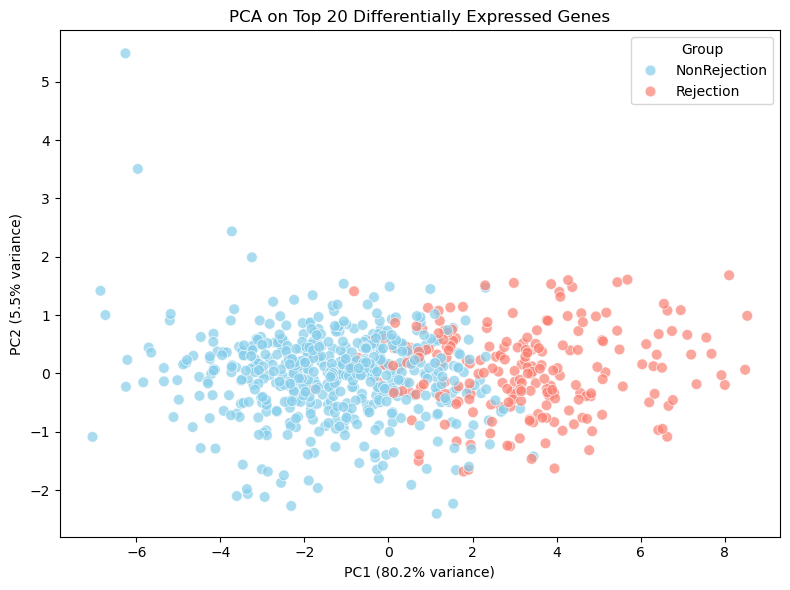

Explained variance ratio by PC1 and PC2: [0.80204142 0.05498212]


In [36]:

# Select top 20 DE genes (t_results is from the full dataset)
top_genes = t_results.sort_values('p_adj').head(20)['Gene'].tolist()

# Use the full transposed expression matrix (samples as rows, genes as columns)
X_top = df_T[top_genes].copy()

# PCA 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_top)

# Combine with group labels (aligned by Sample ID) 
pca_df = pd.DataFrame(X_pca, index=X_top.index, columns=['PC1', 'PC2'])

# Align labels
group_series = target_adjusted.set_index('Sample')['Cluster'].map({0:'NonRejection', 1:'Rejection'})
pca_df['Group'] = group_series.loc[X_top.index].values

# Plot PCA 
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Group',
    data=pca_df,
    palette=['skyblue','salmon'],
    alpha=0.7,
    s=60
)
plt.title("PCA on Top 20 Differentially Expressed Genes")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Group")
plt.tight_layout()
plt.show()

# Explained variance
print("Explained variance ratio by PC1 and PC2:", pca.explained_variance_ratio_[:2])
